In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import spearmanr, pearsonr
pd.options.mode.copy_on_write = True
'''
plot_com_variable(df, comunidades, variables, tipo = 'linea')
plot_todas_comunidades(df, variable, comunidades=None)
plot_dual_axis(df, comunidad, var1, var2, x="año")
correlacion_com_bivariante(df, comunidades, variable1, variable2,alpha = 0.05)
'''
import sys
from pathlib import Path

ROOT_DIR = Path().resolve().parents[1]
sys.path.append(str(ROOT_DIR))

from src import utils as ut

In [3]:
df = pd.read_csv('../../data/processed/dataset_final.csv')
comunidades = list(df.comunidad_autonoma.unique())

In [4]:
def filtrar_columna(df:pd.DataFrame, columna:str):
    '''
    Función para dividir un Dataset, en una lista de Dataset según los valores de una columna.
    '''
    lista_df = []
    lista_valores = df[columna].unique().tolist()
    for valor in lista_valores:
        lista_df.append(df[df[columna] == valor].set_index(columna))
    return lista_df

In [5]:
df_com = filtrar_columna(df, 'comunidad_autonoma')

In [6]:
corr_matrices = {df.index[0]: df.corr() for df in df_com}

## Hipotesis: Incapacidad de hacer frente a gastos económicos imprevistos vs Dificultades para llegar a fin de mes

- **Hipótesis nula (H₀₁):**  
  No existe correlación entre el Incapacidad de hacer frente a gastos económicos imprevistos y el porcentaje de población con dificultad para llegar a fin de mes en una comunidad autónoma a lo largo del tiempo.

- **Hipótesis alternativa (H₁₁):**  
  Existe una correlación positiva entre la incapacidad de hacer frente a gastos económicos imprevistos y la dificultad para llegar a fin de mes,de modo que a mayor incapacidad de hacer frente a gastos económicos imprevistos se asocian con mayores dificultades económicas en los hogares.

In [7]:
for comunidad, datos in corr_matrices.items():
    print(comunidad, '||', datos.loc['inc_gastos_imprevistos', 'dificultad_fin_mes'])

Andalucía || 0.880456432690358
Aragón || 0.5273058120009407
Asturias || 0.09883126000766104
Balears || 0.5314339137201584
Canarias || 0.828041745170985
Cantabria || 0.34292449868006236
Castilla - La Mancha || 0.36654710510970295
Castilla Y León || 0.49774159502247306
Cataluña || 0.6917929132588149
Ceuta || 0.4321081781768041
Comunitat Valenciana || 0.7973846716279227
Extremadura || -0.03741153301846906
Galicia || 0.8063572815458133
Madrid || 0.8607178193477342
Melilla || 0.4014743423095999
Murcia || 0.7986214361987759
Navarra || 0.5668342412410371
País Vasco || 0.5478003345805621
Rioja || 0.7954126869693681


In [13]:
ut.correlacion_com_bivariante(df, comunidades, 'inc_gastos_imprevistos', 'dificultad_fin_mes',alpha = 0.05)

Coeficiente de correlación de Spearman entre inc_gastos_imprevistos y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 ['Andalucía', 'Aragón', 'Canarias', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Madrid', 'Murcia', 'País Vasco', 'Rioja']
 [0.903, 0.645, 0.798, 0.705, 0.569, 0.779, 0.785, 0.886, 0.836, 0.581, 0.767]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Asturias', 'Balears', 'Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Extremadura', 'Melilla', 'Navarra']
 [0.876, 0.098, 0.134, 0.169, 0.051, 0.899, 0.106, 0.067]


In [14]:
ut.correlacion_com_bivariante(df, comunidades, 'inc_gastos_imprevistos', 'dificultad_fin_mes',alpha = 0.1)

Coeficiente de correlación de Spearman entre inc_gastos_imprevistos y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Aragón', 'Balears', 'Canarias', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Madrid', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [0.903, 0.645, 0.459, 0.798, 0.531, 0.705, 0.569, 0.779, 0.785, 0.886, 0.836, 0.502, 0.581, 0.767]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Asturias', 'Cantabria', 'Castilla - La Mancha', 'Extremadura', 'Melilla']
 [0.876, 0.134, 0.169, 0.899, 0.106]



En primer lugar, se analizó la correlación de Spearman entre ambas variables utilizando un nivel de significación del 5 % (α = 0,05), observándose significación estadística en varias Comunidades Autónomas.

Posteriormente, se repitió el análisis ampliando el nivel de significación al 10 % (α = 0,10). Bajo este criterio, en las Comunidades de **Andalucía, Aragón, Baleares, Canarias, Castilla y León, Cataluña, Ceuta, Comunitat Valenciana, Galicia, Madrid, Murcia, Navarra, País Vasco y La Rioja** se pudo rechazar la hipótesis nula con un **90 % de confianza**, evidenciando una correlación entre las variables.

En todos estos casos, la correlación fue **positiva**, lo que indica que a mayor dificultad para llegar a fin de mes, mayor es la incapacidad para afrontar gastos imprevistos.  
En cambio, en **Asturias, Cantabria, Castilla-La Mancha, Extremadura y Melilla** no se encontró evidencia estadística suficiente para confirmar dicha relación.


*Para los gráficos seleccionamos solo Comunidades con evidencia estadística (según α = 0,10).   
Elegimos dos con correlación alta (Andalucía y Madrid), dos con correlación más baja dentro de las significativas (Baleares y Castilla y León) y una adicional como referencia (La Rioja), para visualizar el patrón general sin incluir todas las Comunidades a la vez.*


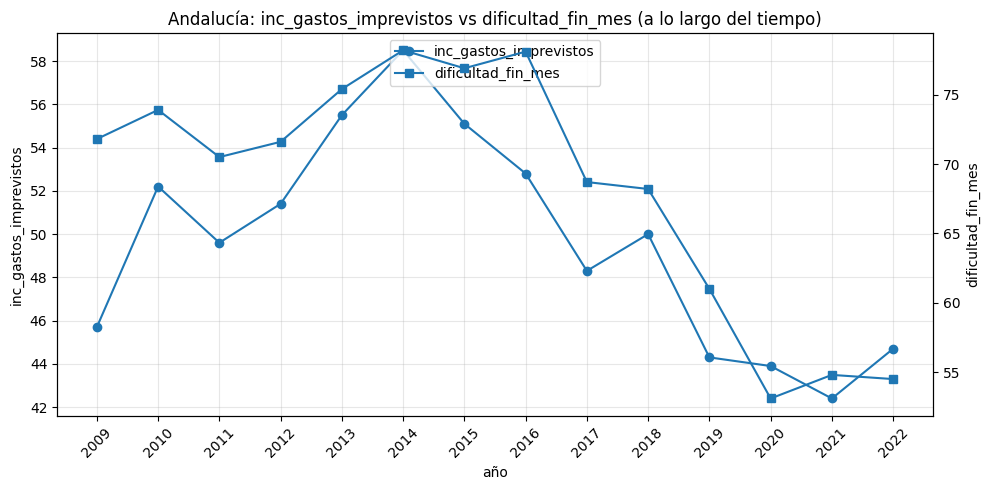

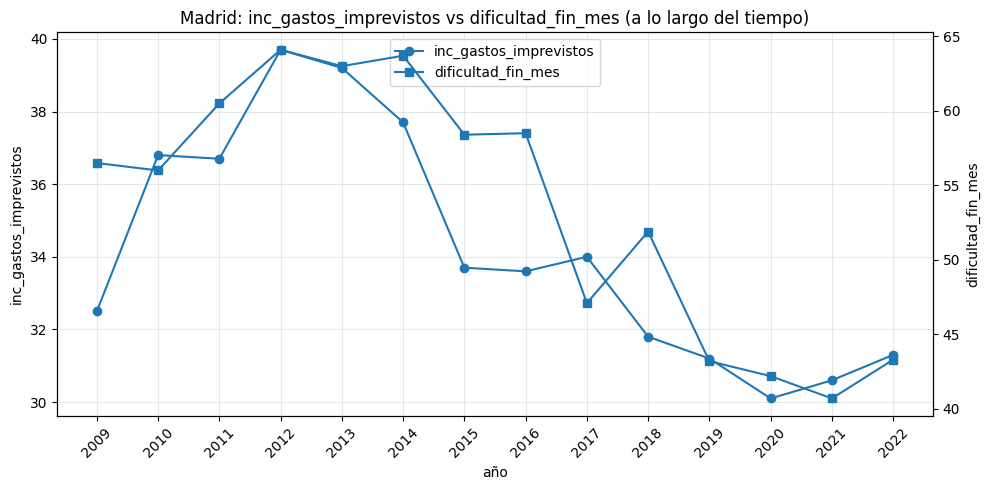

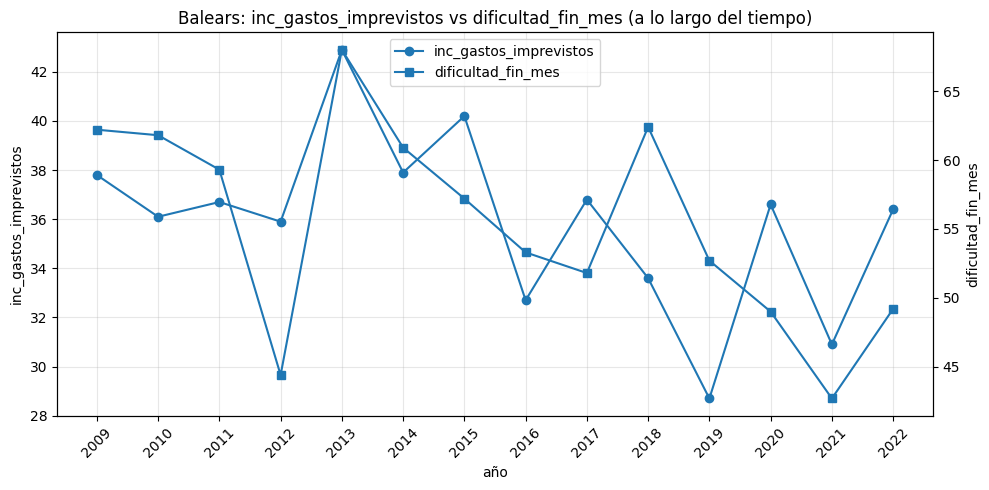

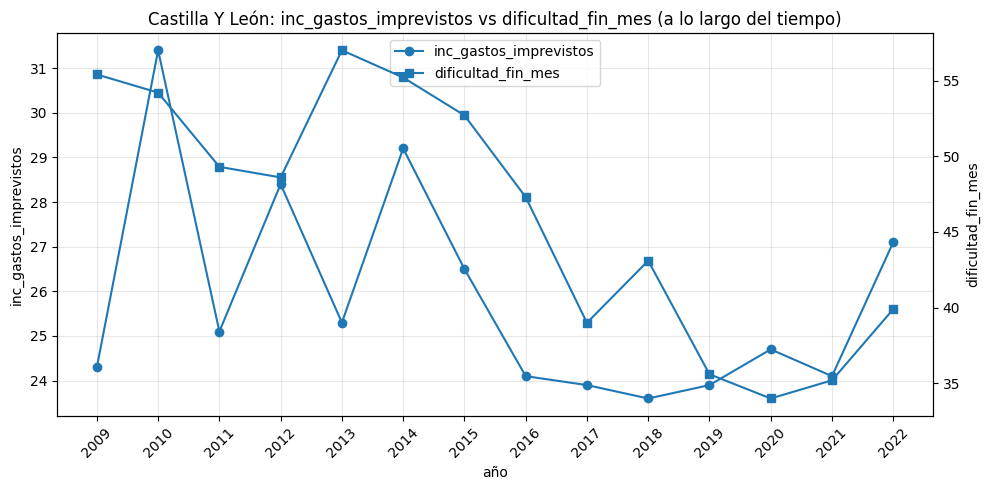

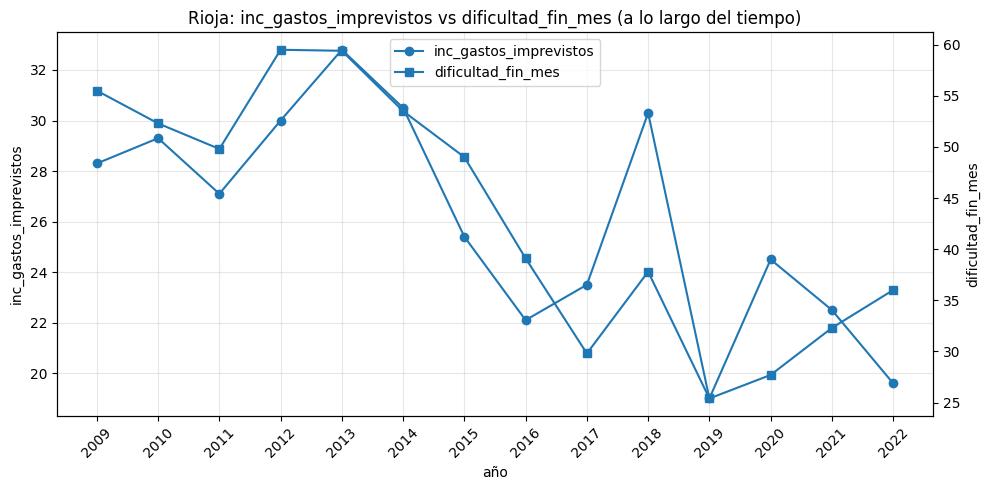

In [16]:
ut.plot_dual_axis(df, ['Andalucía', 'Madrid', 'Balears', 'Castilla Y León', 'Rioja'], 'inc_gastos_imprevistos', 'dificultad_fin_mes', x="año")

Al analizar la evolución temporal de ambas variables por Comunidad Autónoma, se observa que en aquellas con mayor correlación (como Andalucía y Madrid) las curvas presentan un comportamiento muy similar a lo largo del tiempo, con ascensos y descensos que tienden a coincidir.

En las Comunidades con correlaciones más bajas, aunque estadísticamente significativas (como Baleares y Castilla y León), se aprecia una mayor disparidad entre las series, con periodos en los que las variables evolucionan de forma menos sincronizada.

Por su parte, La Rioja muestra un comportamiento intermedio, combinando tramos de evolución conjunta con otros de mayor variabilidad, lo que es coherente con su coeficiente de correlación.


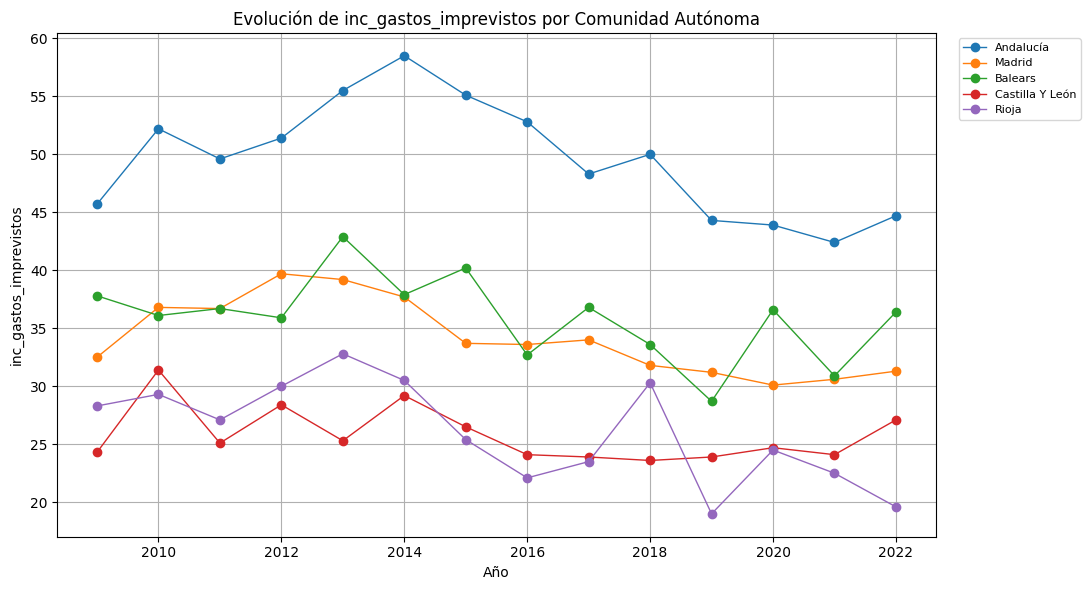

In [17]:
fig = ut.plot_todas_comunidades(df, 'inc_gastos_imprevistos', ['Andalucía', 'Madrid', 'Balears', 'Castilla Y León', 'Rioja'] )

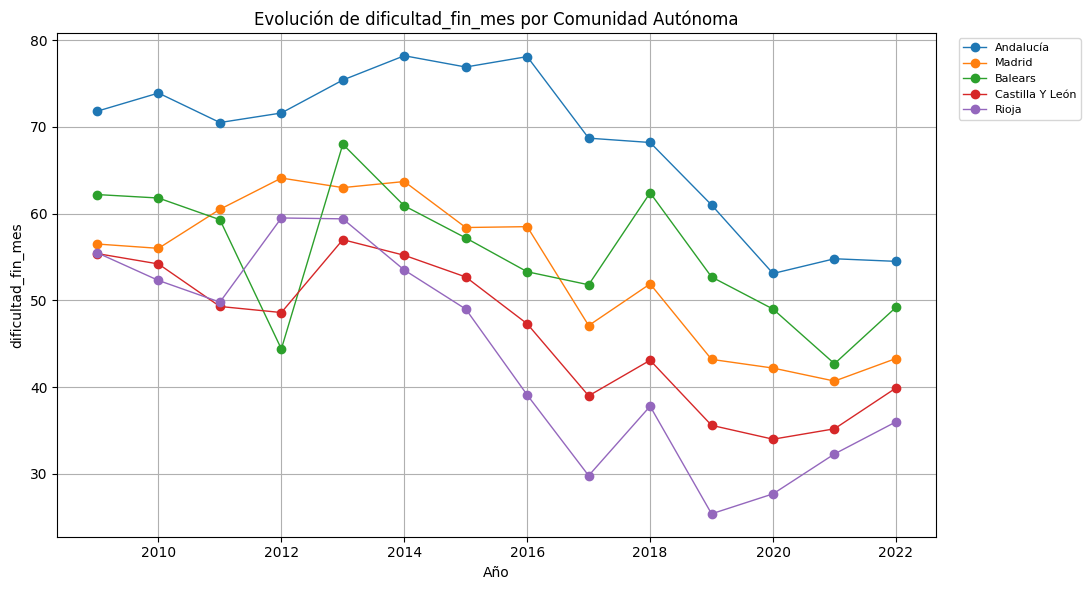

In [19]:
fig = ut.plot_todas_comunidades(df, 'dificultad_fin_mes', ['Andalucía', 'Madrid', 'Balears', 'Castilla Y León', 'Rioja'])

Al analizar conjuntamente la evolución temporal de la dificultad para llegar a fin de mes y de la incapacidad para afrontar gastos imprevistos en las Comunidades seleccionadas, se observan patrones coherentes entre ambas variables.

En términos de nivel, Andalucía presenta sistemáticamente valores más elevados en ambos indicadores, mientras que Castilla y León y La Rioja se sitúan en niveles inferiores, con Madrid y Baleares en una posición intermedia. Estas diferencias reflejan la heterogeneidad territorial existente.

Desde el punto de vista temporal, ambas variables muestran tendencias similares dentro de cada Comunidad, con fases de aumento en los primeros años del período y descensos posteriores, especialmente en la segunda mitad de la serie. En las Comunidades con mayor correlación, estas variaciones tienden a producirse de forma más sincronizada, mientras que en aquellas con correlaciones más bajas se aprecia una mayor disparidad en la evolución de las series.

En conjunto, las representaciones gráficas refuerzan los resultados del análisis de correlación, mostrando una mayor similitud en la evolución temporal de ambas variables en las Comunidades con asociaciones más fuertes.


*Ahora graficamos las comunidades que no se encontró evidencia estadística suficiente para confirmar dicha relación.*

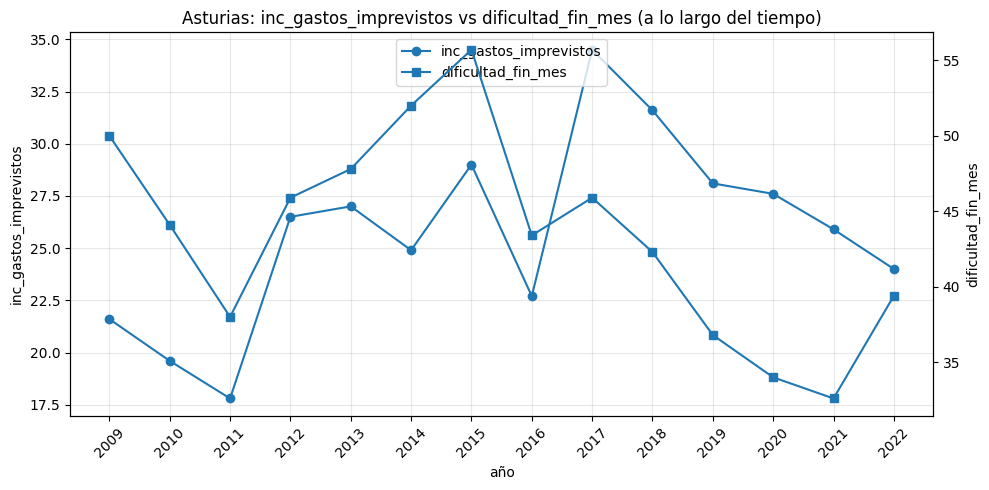

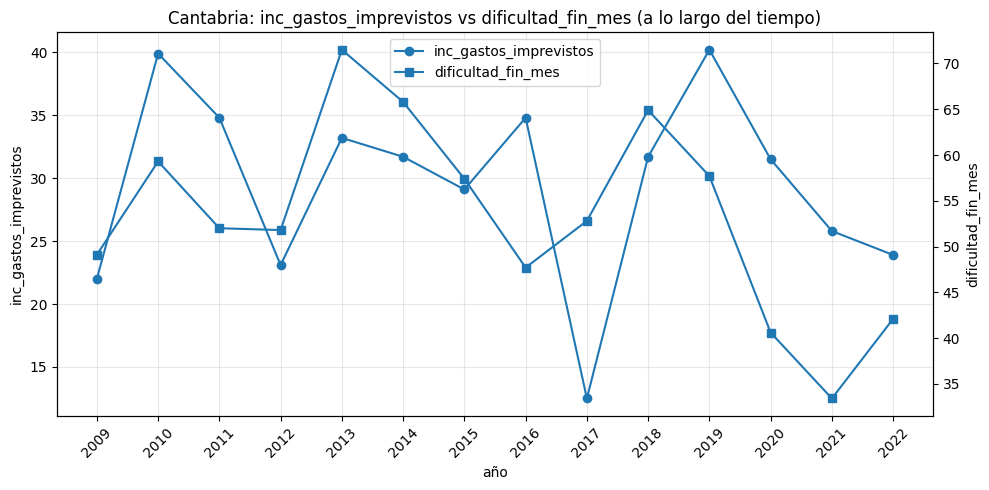

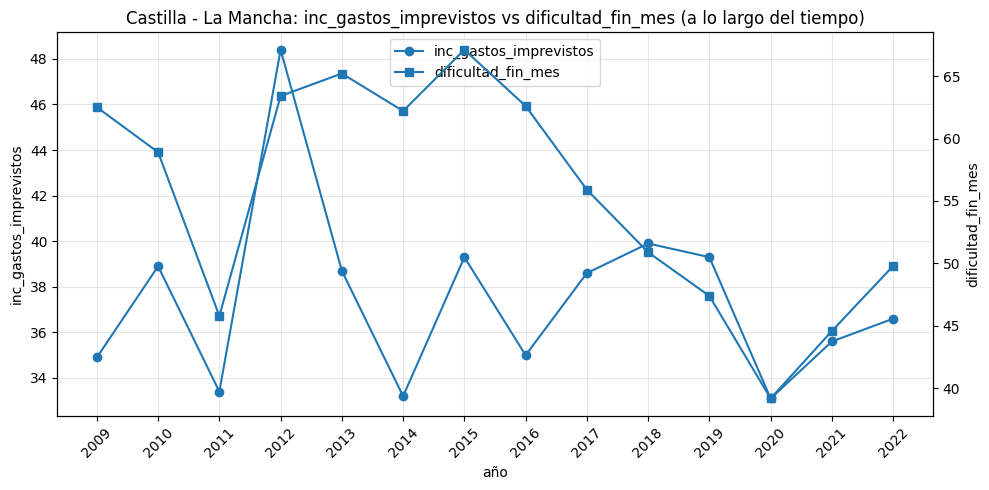

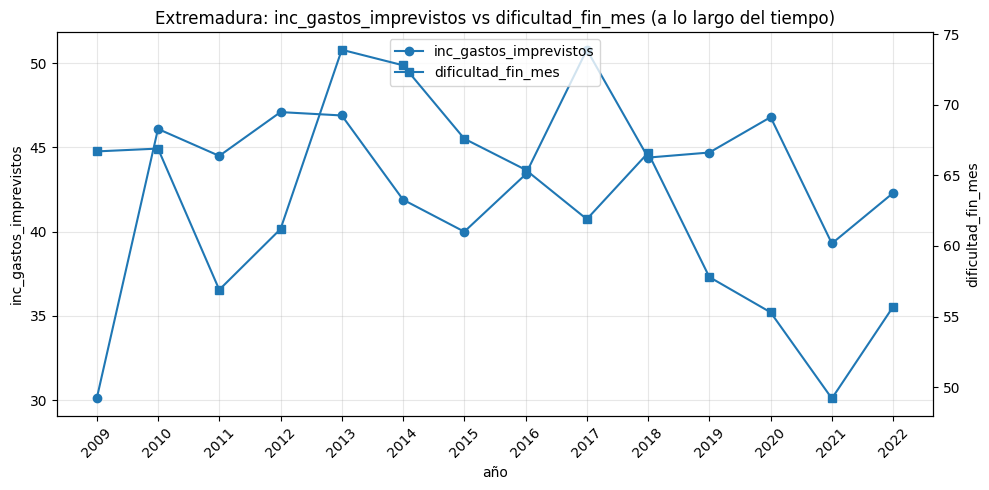

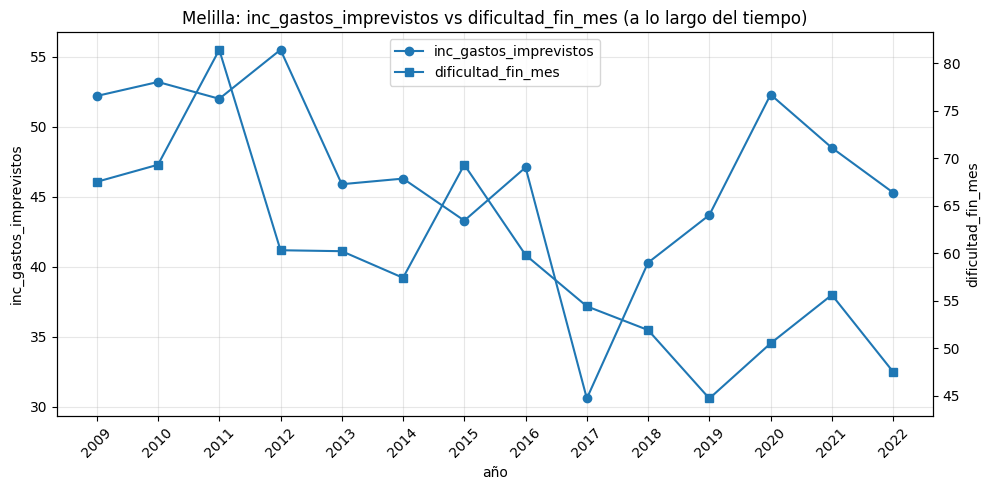

In [18]:
ut.plot_dual_axis(df, ['Asturias', 'Cantabria', 'Castilla - La Mancha', 'Extremadura', 'Melilla'], 'inc_gastos_imprevistos', 'dificultad_fin_mes', x="año")

En las Comunidades Autónomas donde no se obtuvo significación estadística en el análisis de correlación, la inspección visual de las series temporales sugiere que puede existir cierta relación entre las variables en algunos tramos del período. Sin embargo, la presencia de picos abruptos, cambios interanuales marcados y una falta de sincronía sostenida entre ambas series impide que dicha relación se mantenga de forma consistente a lo largo del tiempo.

Por este motivo, aunque visualmente puedan observarse tendencias similares en determinados años, el coeficiente de correlación no permite rechazar la hipótesis nula desde el punto de vista estadístico. Esto no implica necesariamente la ausencia de relación entre las variables, sino que dicha relación no puede confirmarse de manera estadísticamente robusta con los datos analizados.

### PIB per cápita vs indicadores socioeconómicos
 Una vez analizada la relación entre la dificultad para llegar a fin de mes y la incapacidad para afrontar gastos imprevistos, exploraremos cómo estos indicadores socioeconómicos se relacionan con el PBI per cápita a lo largo del tiempo.

In [22]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'dificultad_fin_mes',alpha = 0.05)

Coeficiente de correlación de Spearman entre pib_pc y dificultad_fin_mes

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Murcia', 'Navarra', 'País Vasco', 'Rioja']
 [-0.745, -0.622, -0.767, -0.64, -0.679, -0.846, -0.754, -0.771, -0.801, -0.578, -0.877, -0.868, -0.78, -0.559, -0.793, -0.837]


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Balears', 'Cantabria', 'Melilla']
 [0.681, 0.122, 0.118]


In [24]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'inc_gastos_imprevistos',alpha = 0.1)


Coeficiente de correlación de Spearman entre pib_pc y inc_gastos_imprevistos

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Andalucía', 'Balears', 'Canarias', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Madrid', 'Murcia', 'Rioja']
 [-0.771, -0.481, -0.78, -0.504, -0.749, -0.666, -0.666, -0.741, -0.833, -0.794, -0.723]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Aragón', 'Asturias', 'Cantabria', 'Castilla - La Mancha', 'Extremadura', 'Melilla', 'Navarra', 'País Vasco']
 [0.84, 0.584, 0.893, 0.84, 0.503, 0.455, 0.788, 0.337]


El análisis de correlación de Spearman mostró, en la mayoría de las Comunidades Autónomas, una asociación negativa entre el PBI y ambas variables, lo que indica que a mayores niveles de PBI per cápita tienden a disminuir estas problemáticas socioeconómicas. Esta relación resulta especialmente consistente en el caso de la dificultad para llegar a fin de mes, donde se observa significación estadística en un mayor número de Comunidades.

En el caso de la incapacidad para afrontar gastos imprevistos, aunque el signo de la correlación es mayoritariamente negativo, la relación no alcanza significación estadística en todas las Comunidades. Tal como se observó en los análisis gráficos previos, la presencia de picos abruptos y una mayor variabilidad interanual pueden dificultar la confirmación estadística de la asociación, aun cuando visualmente se aprecien tendencias similares.


## Hipotesis: Desigualdad de ingresos (S80/S20) vs Población con gasto elevado en vivienda

- **Hipótesis nula (H₀₁):**  
  No existe correlación entre desigualdad de ingresos (S80/S20) y el porcentaje de población población con gasto elevado en vivienda en las comunidades autónomas a lo largo del tiempo.

- **Hipótesis alternativa (H₁₁):**  
  Existe una correlación entre la desigualdad de ingresos (S80/S20) y el porcentaje de población población con gasto elevado en vivienda.

La relación entre la desigualdad de ingresos (S80/S20) y el porcentaje de población con gasto elevado en vivienda resulta conceptualmente esperable, ya que un aumento de la desigualdad implica una mayor brecha entre los hogares con mayores y menores ingresos. En este contexto, una parte de la población puede verse más expuesta a destinar una proporción elevada de sus ingresos al pago de la vivienda.

In [45]:
ut.correlacion_com_bivariante(df, comunidades, 'desigualdad_ing(S80/S20)', 'gasto_elevado_vivienda',alpha = 0.05)


Coeficiente de correlación de Spearman entre desigualdad_ing(S80/S20) y gasto_elevado_vivienda

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Extremadura', 'Madrid', 'Melilla', 'Murcia', 'Rioja']
 [0.636, 0.571, 0.785, 0.722, 0.849, 0.785, 0.533, 0.561, 0.669, 0.814, 0.639, 0.937]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Canarias', 'Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Galicia', 'Navarra', 'País Vasco']
 [0.52, 0.219, 0.207, 0.091, 0.123, 0.101, 0.134]


In [33]:
ut.correlacion_com_bivariante(df, comunidades, 'desigualdad_ing(S80/S20)', 'gasto_elevado_vivienda',alpha = 0.1)

Coeficiente de correlación de Spearman entre desigualdad_ing(S80/S20) y gasto_elevado_vivienda

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'Madrid', 'Melilla', 'Murcia', 'Rioja']
 [0.636, 0.571, 0.785, 0.722, 0.849, 0.785, 0.533, 0.469, 0.561, 0.669, 0.814, 0.639, 0.937]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Canarias', 'Cantabria', 'Ceuta', 'Galicia', 'Navarra', 'País Vasco']
 [0.52, 0.219, 0.207, 0.123, 0.101, 0.134]


En primer lugar, se analizó la correlación de Spearman entre la desigualdad de ingresos (S80/S20) y el porcentaje de población con gasto elevado en vivienda utilizando un nivel de significación del 5 % (α = 0,05), observándose significación estadística en algunas Comunidades Autónomas.

Posteriormente, se repitió el análisis ampliando el nivel de significación al 10 % (α = 0,10). Bajo este criterio, en las Comunidades de **Andalucía, Aragón, Asturias, Baleares, Castilla-La Mancha, Castilla y León, Cataluña, Comunitat Valenciana, Extremadura, Madrid, Melilla, Murcia y La Rioja** se pudo rechazar la hipótesis nula con un **90 % de confianza**, evidenciando una asociación entre ambos indicadores.

En todos estos casos, la correlación fue **positiva**, lo que sugiere que mayores niveles de desigualdad de ingresos se asocian con una mayor proporción de población que destina una parte elevada de sus ingresos al gasto en vivienda. Este resultado es coherente con la idea de que, cuando los ingresos no se distribuyen de forma homogénea, los hogares con menores recursos son más vulnerables al impacto de los costos habitacionales.

En cambio, en las Comunidades de **Canarias, Cantabria, Ceuta, Galicia, Navarra y País Vasco** no se encontró evidencia estadística suficiente para confirmar dicha relación, lo que pone de manifiesto la existencia de diferencias territoriales en la dinámica entre desigualdad e impacto del gasto en vivienda.


*Para los gráficos seleccionamos solo Comunidades con evidencia estadística (según α = 0,10).   
Elegimos dos con correlación alta (Castilla - La Mancha y Rioja), dos con correlación más baja dentro de las significativas (Comunitat Valenciana y Extremadura) y una adicional como referencia (Madrid), para visualizar el patrón general sin incluir todas las Comunidades a la vez.*

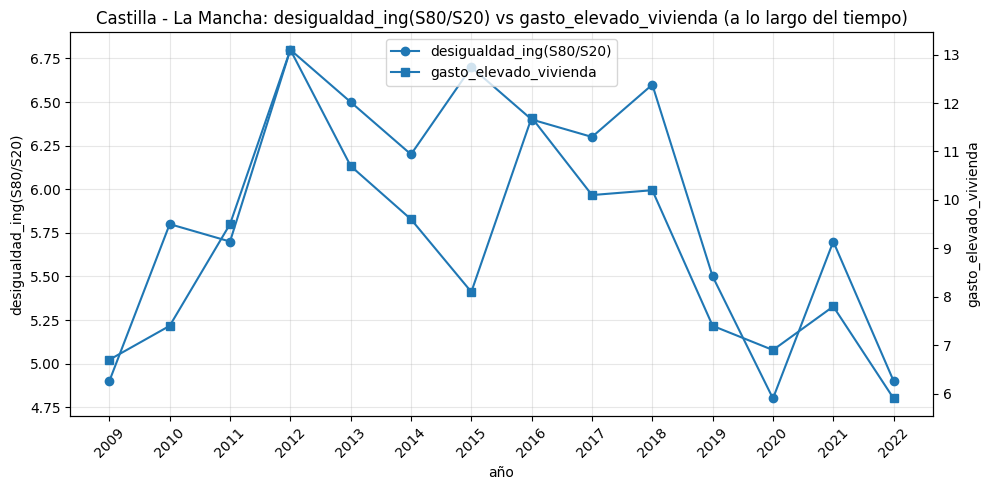

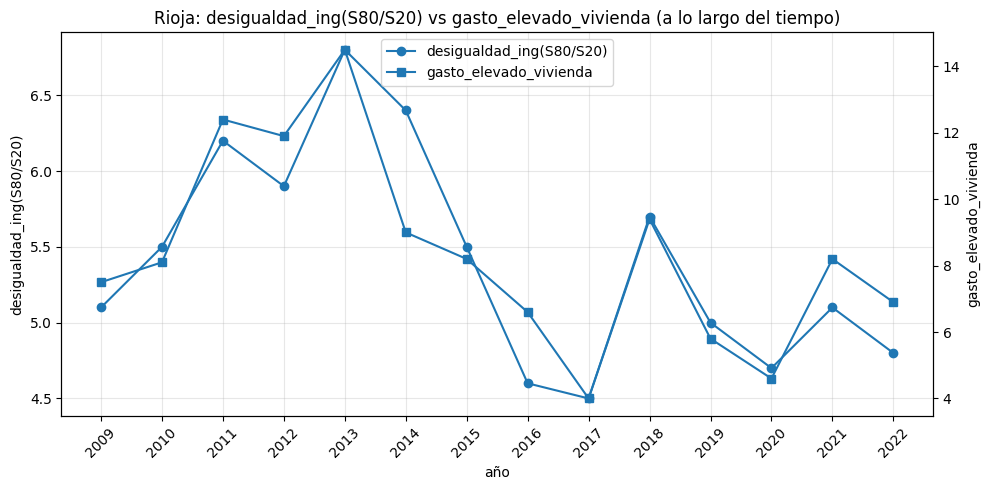

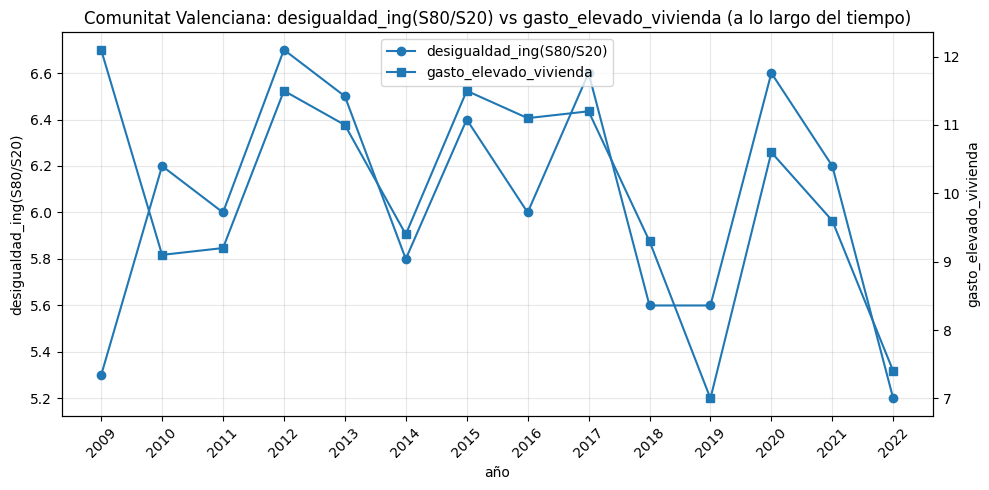

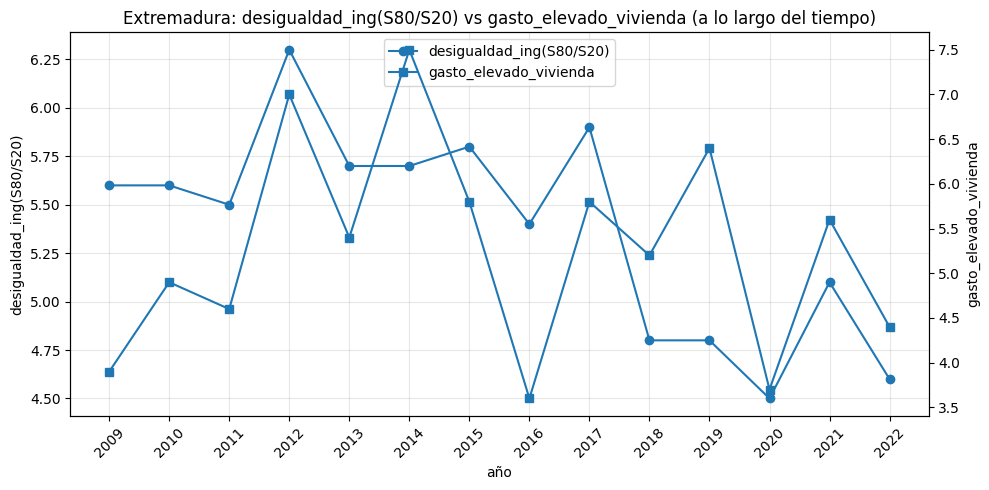

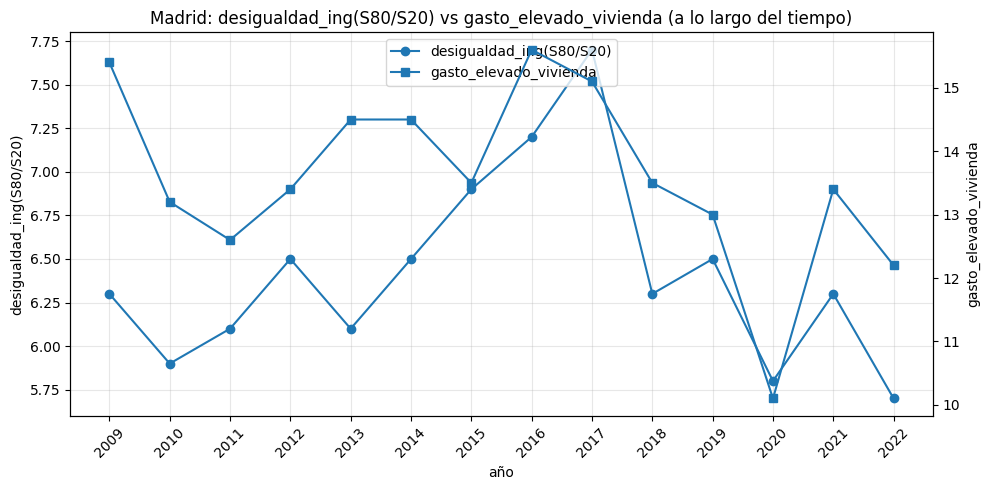

In [34]:
ut.plot_dual_axis(df,['Castilla - La Mancha', 'Rioja', 'Comunitat Valenciana', 'Extremadura','Madrid'], 'desigualdad_ing(S80/S20)', 'gasto_elevado_vivienda', x="año")

Al analizar la evolución temporal de ambas variables por Comunidad Autónoma, se observa que en aquellas con mayor correlación (como La Rioja y Castilla-La Mancha) las curvas presentan un comportamiento más similar a lo largo del tiempo, con variaciones que tienden a coincidir.

En Comunidades con correlaciones más bajas, aunque estadísticamente significativas (como Comunitat Valenciana y Extremadura), se aprecia una mayor disparidad entre las series, con picos puntuales y menor sincronía en su evolución temporal.

Por su parte, Madrid muestra un comportamiento intermedio, combinando tramos de evolución conjunta con otros de mayor variabilidad, lo que resulta coherente con su coeficiente de correlación.


In [38]:
# fig = ut.plot_todas_comunidades(df, 'desigualdad_ing(S80/S20)',['Castilla - La Mancha', 'Rioja', 'Comunitat Valenciana', 'Extremadura','Madrid'] )


In [39]:
# fig = ut.plot_todas_comunidades(df, 'gasto_elevado_vivienda', ['Castilla - La Mancha', 'Rioja', 'Comunitat Valenciana', 'Extremadura','Madrid'] )


*Ahora graficamos las comunidades que no se encontró evidencia estadística suficiente para confirmar dicha relación.*

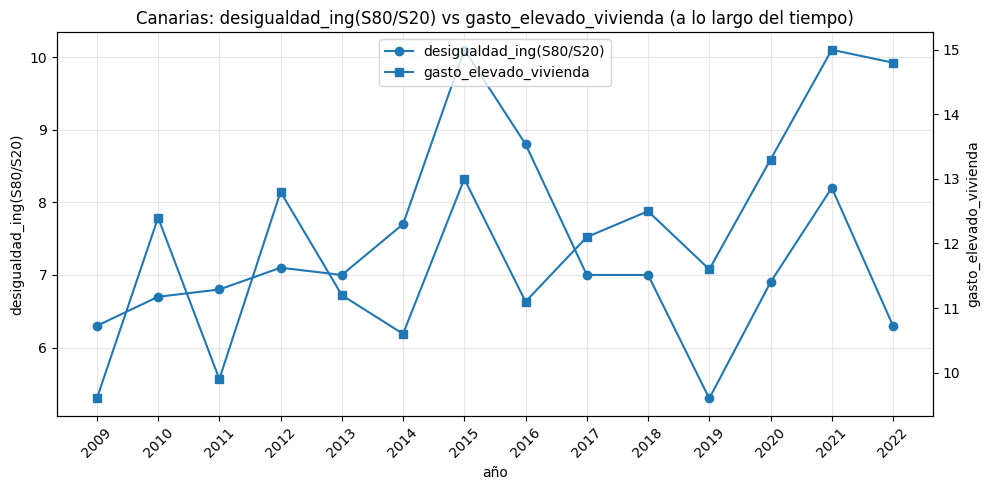

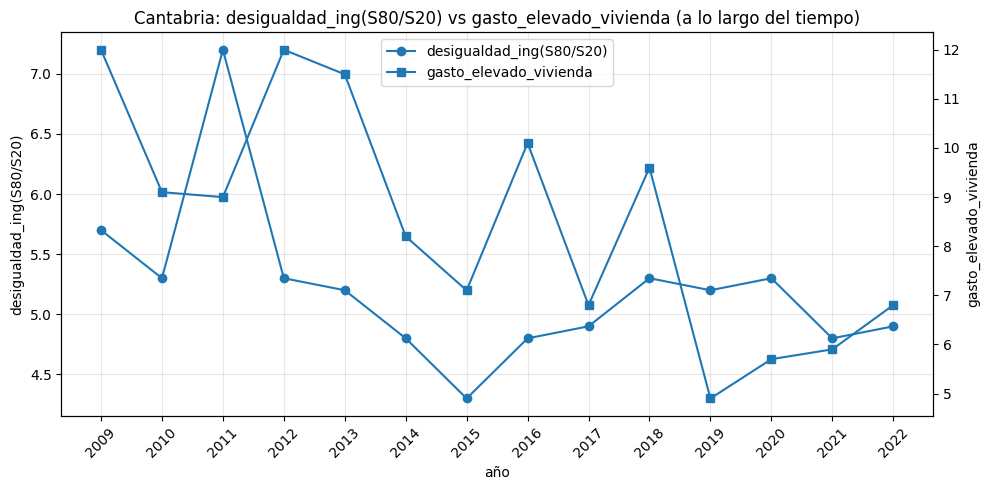

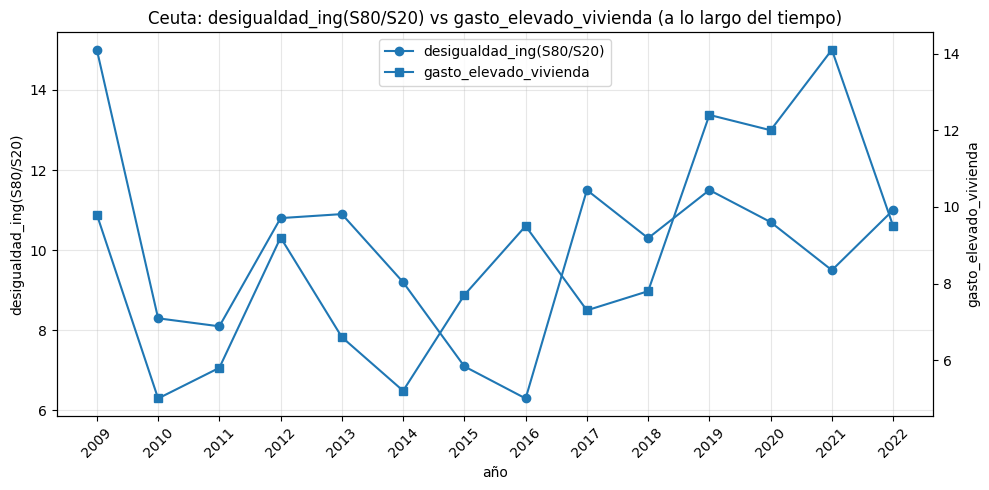

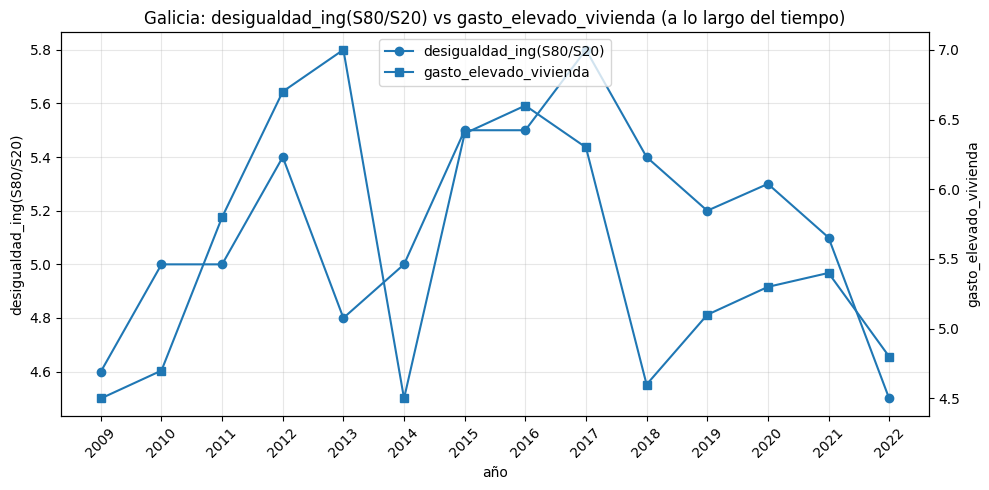

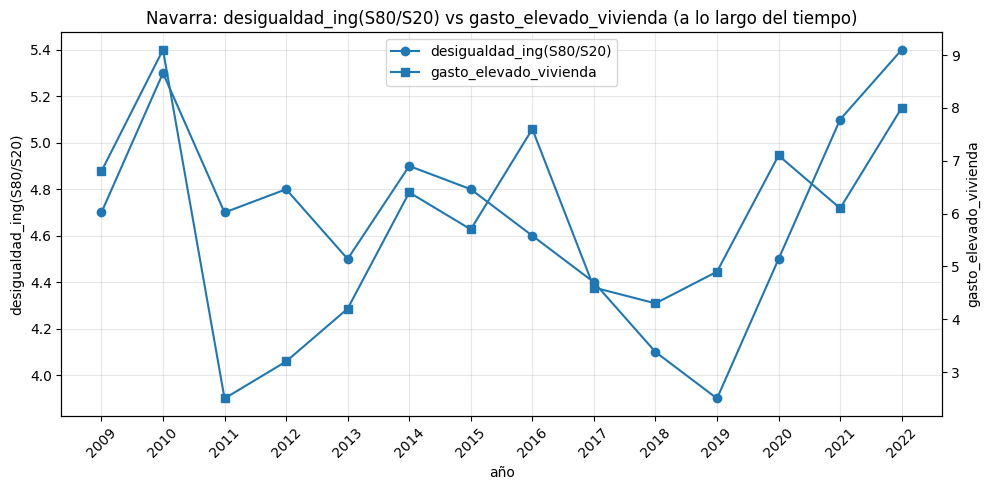

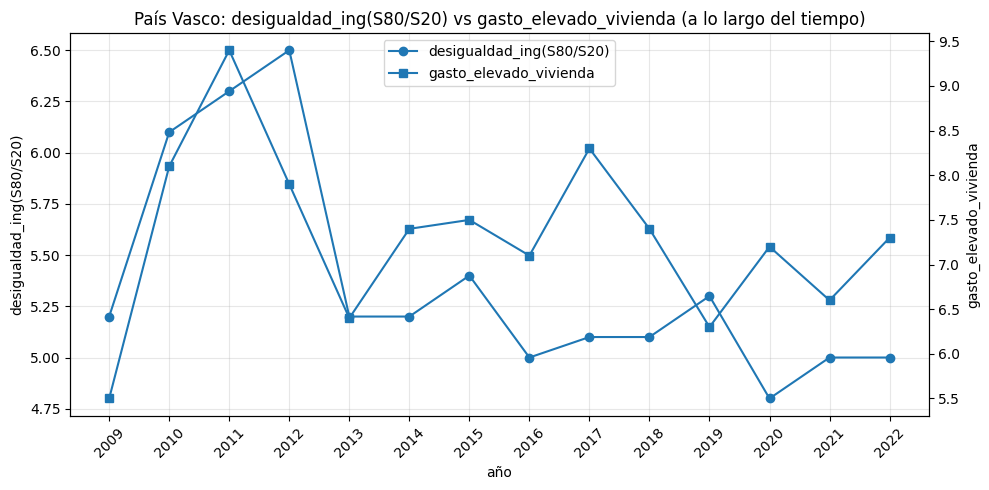

In [35]:
ut.plot_dual_axis(df, ['Canarias', 'Cantabria', 'Ceuta', 'Galicia', 'Navarra', 'País Vasco'], 'desigualdad_ing(S80/S20)', 'gasto_elevado_vivienda', x="año")

En las Comunidades Autónomas donde no se obtuvo significación estadística, las representaciones gráficas muestran una elevada variabilidad interanual, especialmente en el indicador de gasto elevado en vivienda, con picos abruptos que no se acompañan de cambios equivalentes en la desigualdad de ingresos. 

En general, la desigualdad presenta una evolución más gradual, mientras que el gasto elevado en vivienda concentra las mayores oscilaciones, lo que dificulta la identificación de una relación estable entre ambas variables. Esta falta de sincronía a lo largo del tiempo contribuye a que el coeficiente de correlación no permita confirmar una asociación estadísticamente significativa. En comparación con la hipótesis anterior, la relación entre las variables resulta visualmente menos consistente.


### PIB per cápita vs Desigualdad de ingresos (S80/S20)
Con el objetivo de contextualizar los resultados obtenidos en el análisis de la desigualdad de ingresos, se exploró de forma complementaria la relación entre el PBI per cápita y el indicador S80/S20. Este análisis permite evaluar si mayores niveles de riqueza media se asocian con una distribución más equitativa de los ingresos, o si, por el contrario, el crecimiento económico puede coexistir con altos niveles de desigualdad.


In [43]:
ut.correlacion_com_bivariante(df, comunidades,'pib_pc', 'desigualdad_ing(S80/S20)',alpha = 0.1)


Coeficiente de correlación de Spearman entre pib_pc y desigualdad_ing(S80/S20)

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Ceuta']
 [0.46]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Aragón', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Comunitat Valenciana', 'Extremadura', 'País Vasco', 'Rioja']
 [-0.642, -0.535, -0.631, -0.685, -0.47, -0.684, -0.546, -0.667]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Andalucía', 'Asturias', 'Balears', 'Canarias', 'Cantabria', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'Navarra']
 [0.148, 0.359, 0.256, 0.24, 0.879, 0.662, 0.666, 0.236, 0.212, 0.636]


### Población con gasto elevado en vivienda vs Precio de alquiler por m2  

Dado que el indicador de gasto elevado en vivienda refleja la proporción de ingresos destinada al pago habitacional, resulta pertinente explorar el papel del precio del alquiler como posible factor explicativo. En este sentido, se analiza de forma complementaria la relación entre el precio del alquiler y el porcentaje de población con gasto elevado en vivienda, con el objetivo de contextualizar los resultados obtenidos en el análisis de desigualdad de ingresos.

In [42]:
ut.correlacion_com_bivariante(df, comunidades, 'gasto_elevado_vivienda','precio_alquiler_m2',alpha = 0.1)


Coeficiente de correlación de Spearman entre gasto_elevado_vivienda y precio_alquiler_m2

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Canarias']
 [0.516]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Balears', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Ceuta', 'Galicia', 'Murcia']
 [-0.811, -0.671, -0.471, -0.76, -0.616, -0.462, -0.669]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Andalucía', 'Aragón', 'Asturias', 'Cantabria', 'Comunitat Valenciana', 'Extremadura', 'Madrid', 'Melilla', 'Navarra', 'País Vasco', 'Rioja']
 [0.135, 0.503, 0.782, 0.702, 0.109, 0.196, 0.114, 0.294, 0.887, 0.674, 0.433]


El análisis complementario entre el precio del alquiler y el porcentaje de población con gasto elevado en vivienda no muestra una asociación positiva homogénea entre Comunidades Autónomas. Esto indica que el aumento del precio del alquiler, considerado de forma aislada, no explica por sí solo la sobrecarga en el gasto habitacional.

Estos resultados refuerzan la idea de que el gasto elevado en vivienda está estrechamente vinculado a la capacidad económica de los hogares, y en particular al nivel y la distribución de los ingresos. En contextos de mayor desigualdad, los hogares con menores recursos presentan una mayor vulnerabilidad frente a los costos de la vivienda, incluso sin incrementos proporcionales en los precios del alquiler.

Por su parte, la relación entre el PBI per cápita y la desigualdad de ingresos no resulta uniforme entre Comunidades Autónomas, observándose en varios casos una asociación negativa y en otros la ausencia de significación estadística. Esto sugiere que el crecimiento económico medio no garantiza una mejora en la distribución de los ingresos, y que los beneficios del aumento del PBI pueden concentrarse en determinados sectores de la población.


## Hipótesis: Desigualdad de ingresos (S80/S20) vs Tasa de riesgo de pobreza

- **Hipótesis nula (H₀):**  
No existe correlación entre la desigualdad de ingresos (S80/S20) y la tasa de riesgo de pobreza en las Comunidades Autónomas a lo largo del tiempo.

- **Hipótesis alternativa (H₁):**  
Existe una correlación entre la desigualdad de ingresos (S80/S20) y la tasa de riesgo de pobreza en las Comunidades Autónomas a lo largo del tiempo.


In [48]:
ut.correlacion_com_bivariante(df, comunidades, 'desigualdad_ing(S80/S20)', 'riesgo_pobreza',alpha = 0.05)

Coeficiente de correlación de Spearman entre desigualdad_ing(S80/S20) y riesgo_pobreza

Comunidades con correlacion positiva y sus coeficientes (pval < 0.05 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Madrid', 'Melilla', 'Murcia', 'Rioja']
 [0.67, 0.741, 0.73, 0.904, 0.729, 0.797, 0.62, 0.567, 0.768, 0.717, 0.634, 0.878]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.05 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.05 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.05):
 ['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Navarra', 'País Vasco']
 [0.186, 0.881, 0.265, 0.096, 0.077, 0.306, 0.093]


In [49]:
ut.correlacion_com_bivariante(df, comunidades, 'desigualdad_ing(S80/S20)', 'riesgo_pobreza',alpha = 0.1)

Coeficiente de correlación de Spearman entre desigualdad_ing(S80/S20) y riesgo_pobreza

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'País Vasco', 'Rioja']
 [0.67, 0.741, 0.73, 0.904, 0.729, 0.797, 0.62, 0.567, 0.462, 0.488, 0.768, 0.717, 0.634, 0.466, 0.878]


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 []
 []


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Navarra']
 [0.186, 0.881, 0.265, 0.306]


En primer lugar, se analizó la correlación de Spearman entre la desigualdad de ingresos (S80/S20) y la tasa de riesgo de pobreza utilizando un nivel de significación del 5 % (α = 0,05), observándose significación estadística en varias Comunidades Autónomas.

Posteriormente, se repitió el análisis ampliando el nivel de significación al 10 % (α = 0,10). Bajo este criterio, en las Comunidades de **Andalucía, Aragón, Asturias, Baleares, Canarias, Castilla-La Mancha, Castilla y León, Cataluña, Extremadura, Galicia, Madrid, Melilla, Murcia, País Vasco y La Rioja** se pudo rechazar la hipótesis nula con un **90 % de confianza**, evidenciando una asociación entre ambos indicadores.

En todos estos casos, la correlación fue **positiva**, lo que sugiere que mayores niveles de desigualdad de ingresos se asocian con una mayor tasa de riesgo de pobreza. Este resultado es coherente con la idea de que una distribución más desigual de los ingresos incrementa la proporción de población en situación de vulnerabilidad económica.

En cambio, en las Comunidades de **Cantabria, Ceuta, Comunitat Valenciana y Navarra** no se encontró evidencia estadística suficiente para confirmar dicha relación, lo que pone de manifiesto la existencia de diferencias territoriales en la dinámica entre desigualdad de ingresos y riesgo de pobreza.


*Para los gráficos seleccionamos solo Comunidades con evidencia estadística (según α = 0,10).   
Elegimos dos con correlación alta (Baleares y Rioja), dos con correlación más baja dentro de las significativas (Extremadura y País Vasco) y una adicional como referencia (Madrid), para visualizar el patrón general sin incluir todas las Comunidades a la vez.*

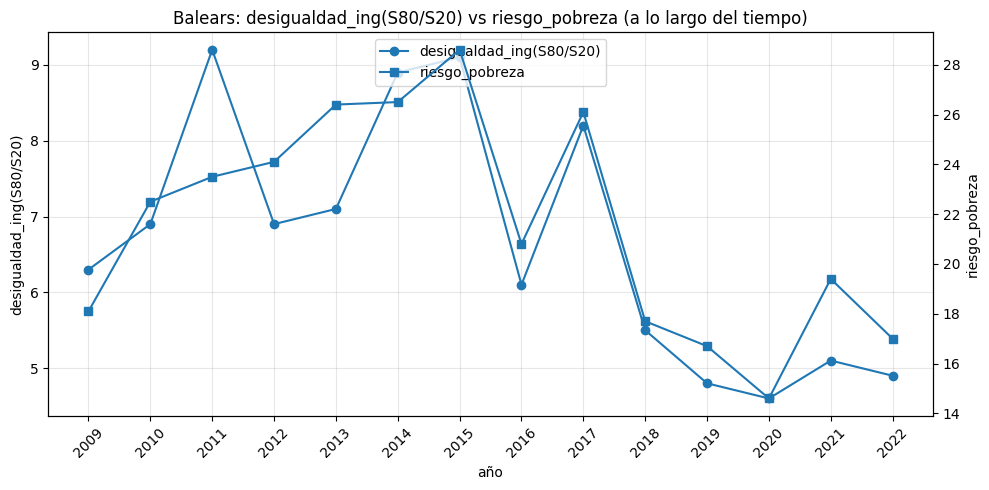

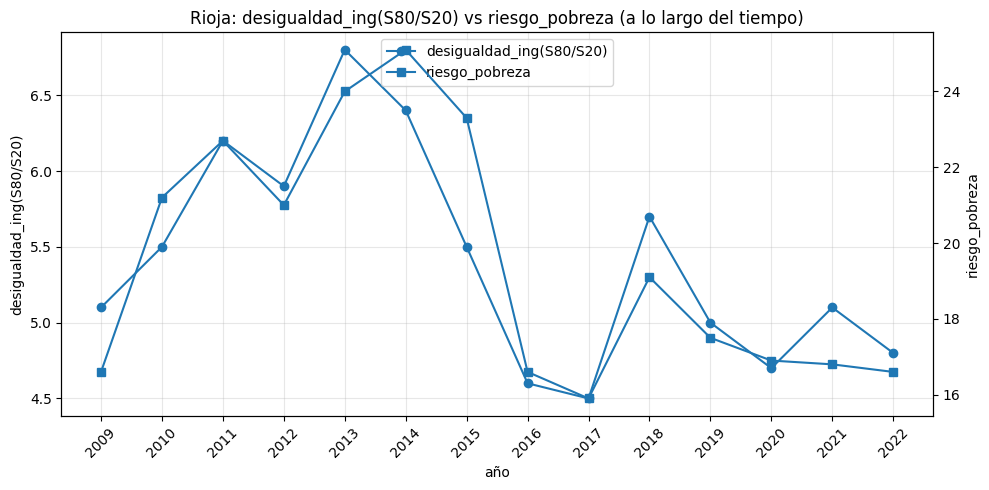

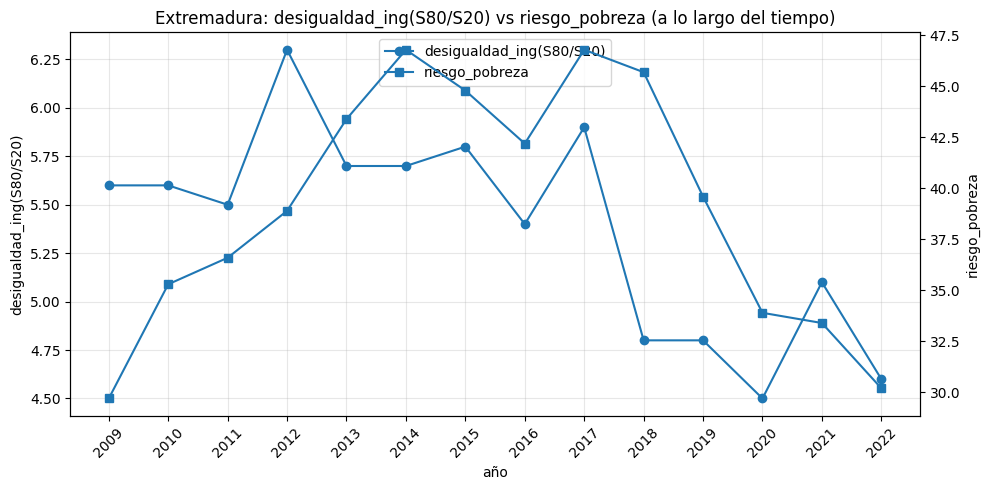

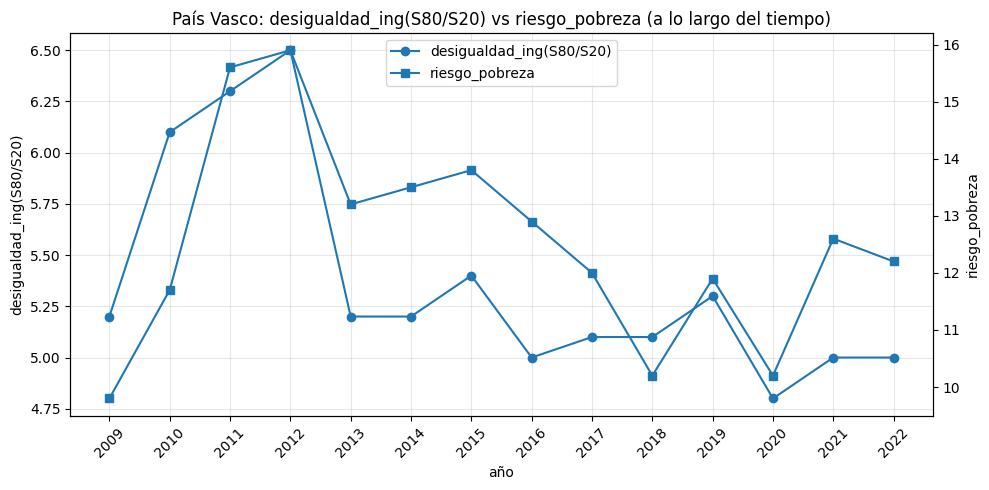

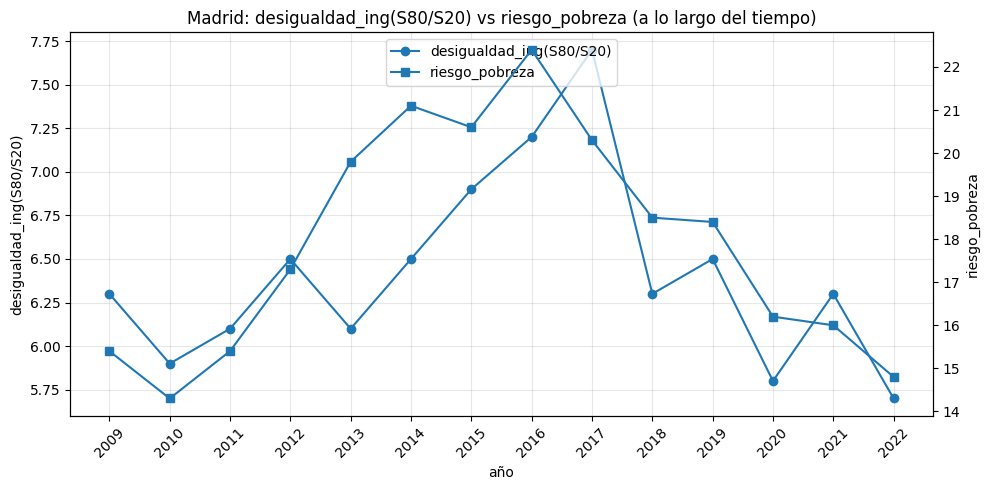

In [56]:
ut.plot_dual_axis(df,['Balears','Rioja' ,'Extremadura','País Vasco' ,'Madrid'], 'desigualdad_ing(S80/S20)',  'riesgo_pobreza', x="año")

Al analizar la evolución temporal conjunta de la desigualdad de ingresos (S80/S20) y la tasa de riesgo de pobreza en las Comunidades seleccionadas, se observa que en Baleares y La Rioja ambas variables presentan un comportamiento muy similar a lo largo del tiempo, con trayectorias paralelas y descensos y aumentos que tienden a coincidir, lo que resulta coherente con los elevados coeficientes de correlación obtenidos.

En Extremadura y País Vasco, si bien la relación sigue siendo positiva, las series muestran una mayor variabilidad interanual, con picos más marcados y una menor sincronía temporal, lo que explica coeficientes de correlación más moderados.

Por su parte, Madrid presenta nuevamente un comportamiento intermedio, combinando tramos de evolución conjunta con otros de mayor fluctuación, en un patrón similar al observado en hipótesis previas.


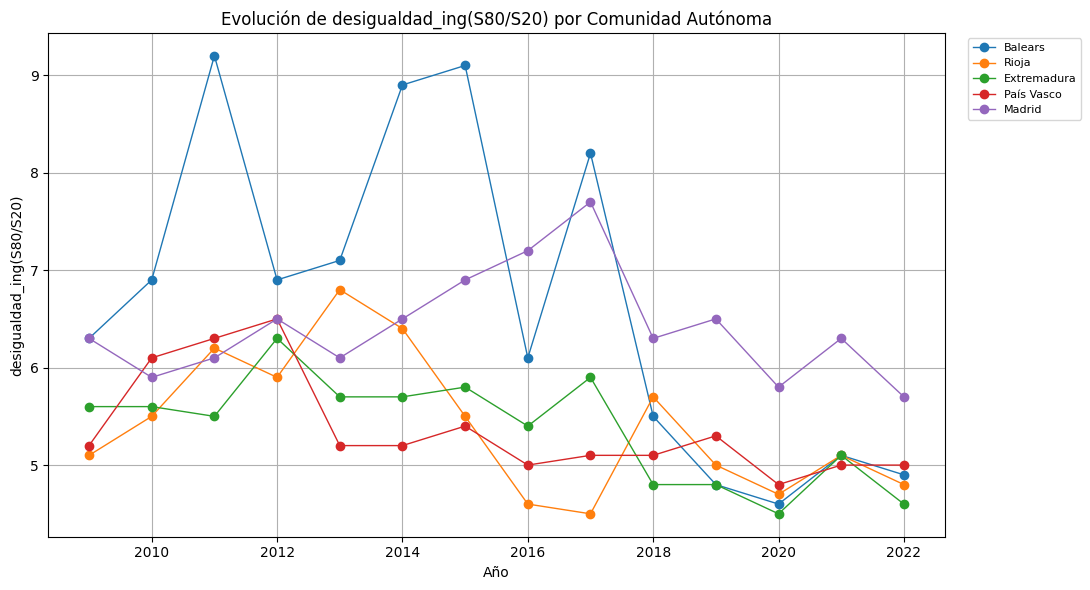

In [57]:
fig = ut.plot_todas_comunidades(df, 'desigualdad_ing(S80/S20)',['Balears','Rioja' ,'Extremadura','País Vasco' ,'Madrid'])


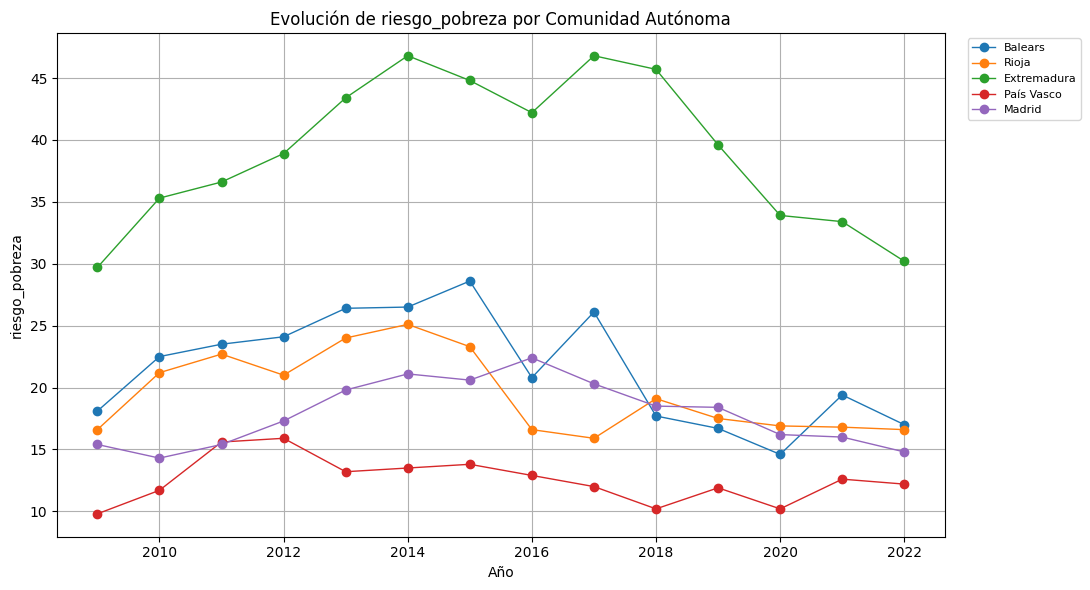

In [58]:
fig = ut.plot_todas_comunidades(df,  'riesgo_pobreza',['Balears','Rioja' ,'Extremadura','País Vasco' ,'Madrid'])


Al analizar conjuntamente la evolución de la desigualdad de ingresos (S80/S20) y la tasa de riesgo de pobreza, se observa que ambas variables no siempre evolucionan de forma paralela entre Comunidades Autónomas.

En Baleares, la desigualdad de ingresos presenta picos marcados a lo largo del período, mientras que el riesgo de pobreza muestra una evolución más estable, lo que sugiere que aumentos en la desigualdad no se traducen necesariamente en incrementos proporcionales del riesgo de pobreza.

En cambio, Extremadura mantiene niveles elevados de riesgo de pobreza pese a no registrar los valores más altos de desigualdad, evidenciando la influencia del nivel absoluto de ingresos y de la estructura socioeconómica regional.

Por su parte, Madrid combina una desigualdad de ingresos relativamente elevada con un riesgo de pobreza más moderado, lo que refuerza la idea de que la desigualdad refleja la distribución interna de los ingresos, mientras que el riesgo de pobreza está más vinculado al nivel medio de renta.

En conjunto, los resultados indican que la desigualdad de ingresos y el riesgo de pobreza están relacionados, pero reflejan fenómenos distintos: la desigualdad describe cómo se distribuyen los ingresos, mientras que el riesgo de pobreza depende del nivel de ingresos de la población.

*Ahora graficamos las comunidades que no se encontró evidencia estadística suficiente para confirmar dicha relación.*

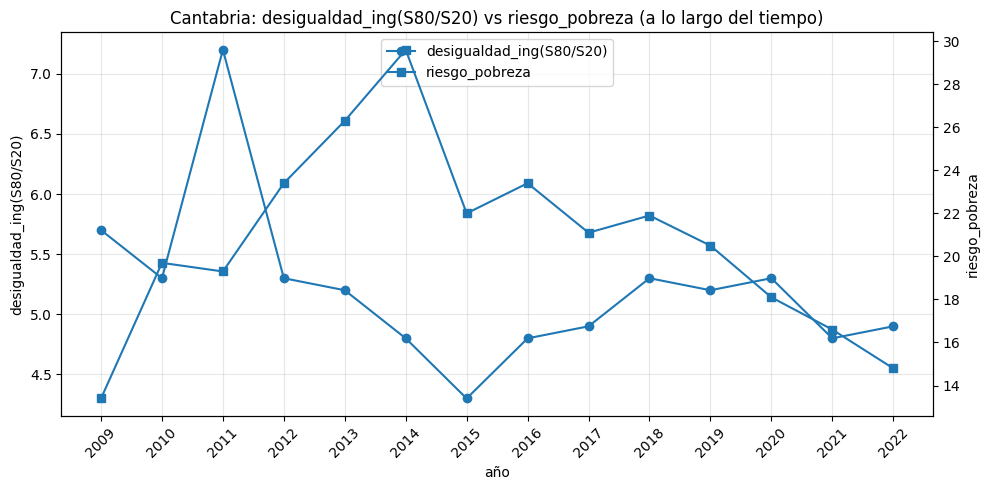

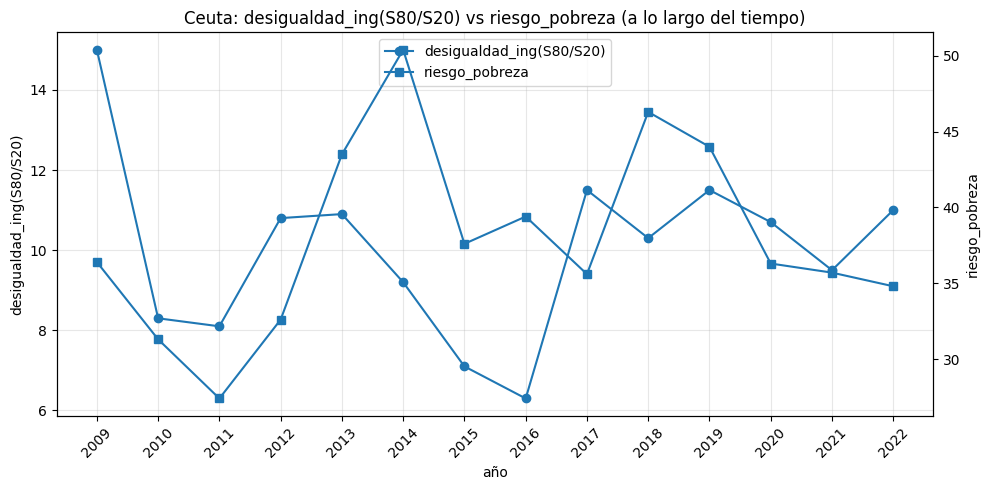

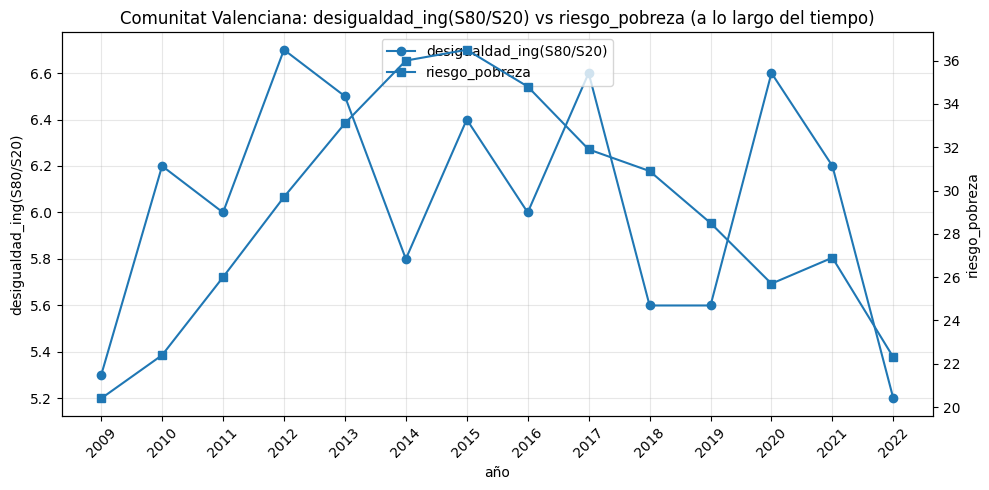

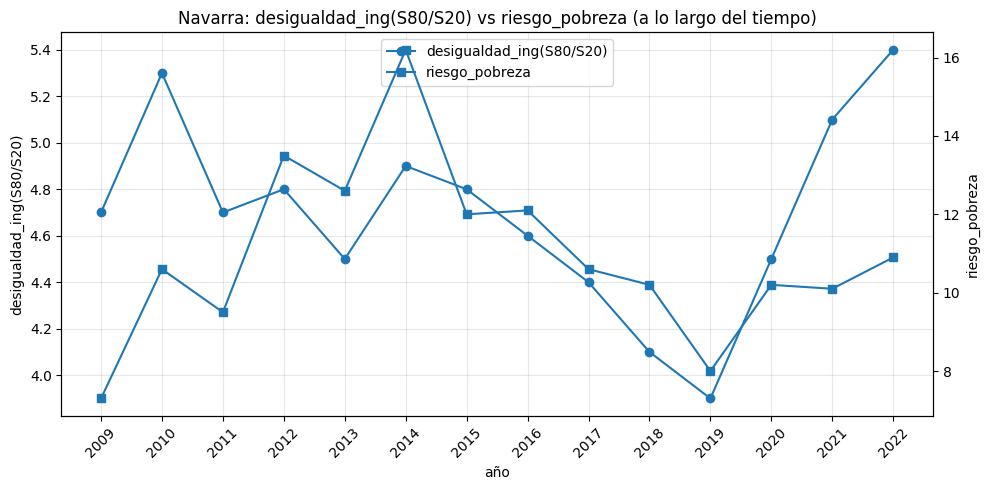

In [62]:
ut.plot_dual_axis(df,['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Navarra'], 'desigualdad_ing(S80/S20)',  'riesgo_pobreza', x="año")


En las Comunidades Autónomas donde el análisis de Spearman no permitió rechazar la hipótesis nula (p-value > 0,10), la inspección visual de los gráficos muestra que no puede afirmarse una relación clara y estable entre la desigualdad de ingresos (S80/S20) y el riesgo de pobreza a lo largo del tiempo.

En estos casos, si bien en algunos periodos ambas variables presentan trayectorias parcialmente similares, se observan numerosos picos abruptos, cambios de tendencia y tramos desalineados entre las series. Esta alta variabilidad temporal dificulta la identificación de un patrón común sostenido, lo que contribuye a la ausencia de significación estadística en el coeficiente de correlación.

Así, la falta de evidencia estadística no implica la inexistencia absoluta de relación, sino que indica que dicha relación no es suficientemente consistente ni estable en el tiempo como para ser confirmada desde el punto de vista estadístico. La presencia de oscilaciones marcadas en una o ambas variables puede atenuar el valor del coeficiente y explicar los p-values elevados observados.

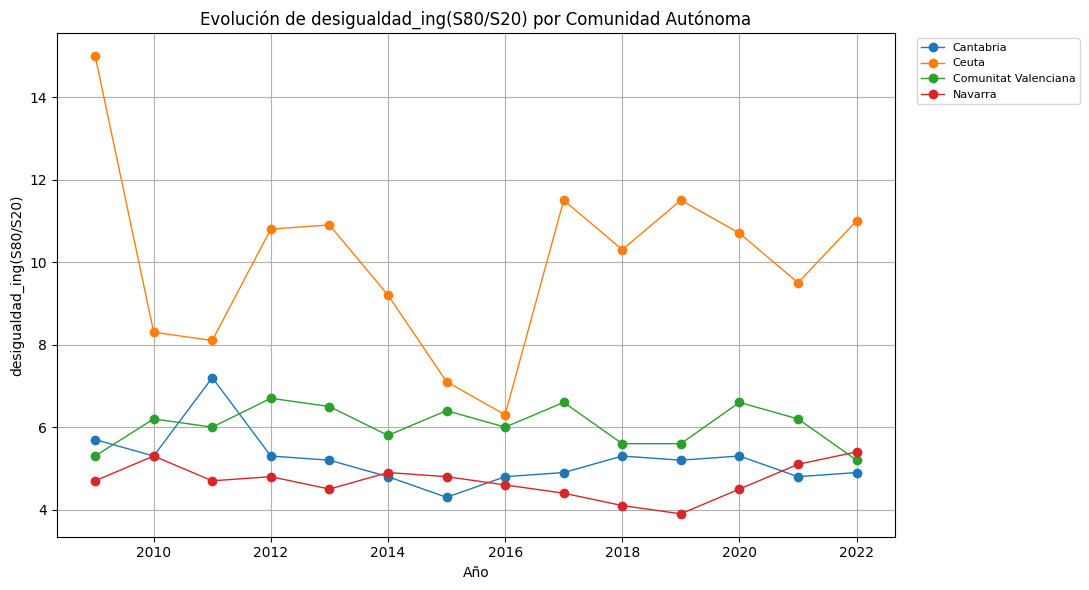

In [60]:
fig = ut.plot_todas_comunidades(df, 'desigualdad_ing(S80/S20)',['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Navarra'])


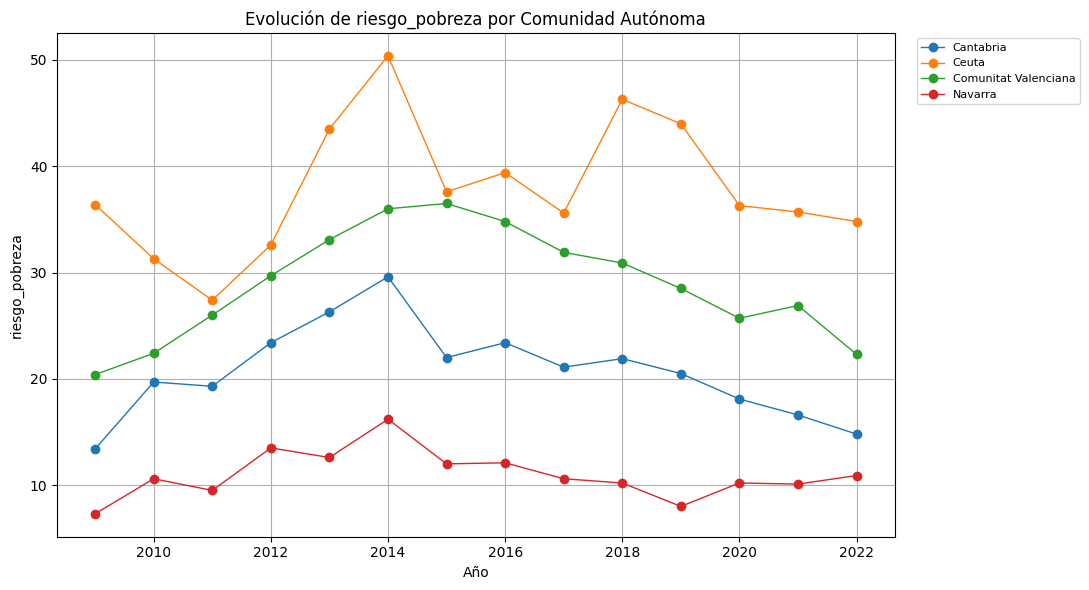

In [61]:
fig = ut.plot_todas_comunidades(df, 'riesgo_pobreza',['Cantabria', 'Ceuta', 'Comunitat Valenciana', 'Navarra'])


Estas observaciones no prueban una relación estadística, pero muestran que desigualdad y riesgo de pobreza pueden coexistir a niveles elevados en un mismo territorio, aun cuando no evolucionen de forma paralela en el tiempo.



In [51]:
ut.correlacion_com_bivariante(df, comunidades, 'pib_pc', 'riesgo_pobreza',alpha = 0.1)


Coeficiente de correlación de Spearman entre pib_pc y riesgo_pobreza

Comunidades con correlacion positiva y sus coeficientes (pval < 0.1 y coef > 0):
 []
 []


Comunidades con correlacion negativa y sus coeficientes (pval < 0.1 y coef < 0):
 ['Cantabria', 'Castilla - La Mancha', 'Castilla Y León', 'Cataluña', 'Navarra', 'Rioja']
 [-0.627, -0.679, -0.591, -0.623, -0.562, -0.651]


Comunidades sin correlacion y sus coeficientes (pval < 0.1 y coef ≈ 0):
 []
 []


Comunidades que no se encontró evidencia estadísticamente significativa y su pval (pval > 0.1):
 ['Andalucía', 'Aragón', 'Asturias', 'Balears', 'Canarias', 'Ceuta', 'Comunitat Valenciana', 'Extremadura', 'Galicia', 'Madrid', 'Melilla', 'Murcia', 'País Vasco']
 [0.208, 0.18, 0.697, 0.221, 0.281, 0.864, 0.144, 0.454, 0.349, 0.302, 0.26, 0.11, 0.151]


El análisis entre PIB per cápita y riesgo de pobreza muestra resultados heterogéneos y escasa significación estadística entre Comunidades Autónomas, lo que indica que el nivel de riqueza regional no explica de forma directa el riesgo de pobreza, reforzando la importancia de la distribución de los ingresos.
